# 320 — Final Feature Set 확정 (lv3 강건성 기반)

**목적**: 16 non-null features 중 추가 5 features 평가 + 5 확정 features 재평가 → final feature set 확정.

**4 그룹**:

| 그룹 | n (baseline) | 비고 |
|---|---|---|
| lv2_human | 51 | 보겸 1인 |
| lv2_macro | 101 | lv2_collector 산출 |
| Balabit_human (`balabit`) | 500 | Balabit derived |
| lv3_balabit_kde | 50 | KDE 매크로 산출 |

**평가 5 추가 features** (Balabit 결측 6 + keyboard 10 배제 후 11-6=5):
- `mouse_acceleration_mean`
- `mouse_jerk_mean`
- `mouse_path_straightness_score`
- `mouse_direction_change_count`
- `mouse_total_travel_distance_px`

**5 확정 features** (315 결과 4/5 도미노 깨짐 — 320-B 에서 함께 재평가):
- `inter_click_interval_ms`
- `mouse_speed_change_mean`
- `mouse_max_speed_px_per_ms`
- `mouse_path_curvature_mean`
- `mouse_avg_speed_px_per_ms`

**가설**: 추가 5 중 일부가 lv3 vs Balabit 비교에서도 분리력 유지 → 강건 신호 후보.

**Caveats**:
- `[min, max]` 실측 range 기반 외부진입율 — outlier 1개로 range 폭 부풀려질 수 있음. 결과 해석 시 group min/max 절대값 함께 검토 (`320pool-03-stats` 별도 표).
- σ ratio 방향: `macro_std / human_std` (작을수록 macro 좁음, 핸드오프 baseline 0.136 정합).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

EDA_DIR = Path.cwd()
if str(EDA_DIR) not in sys.path:
    sys.path.insert(0, str(EDA_DIR))

from trial_loader import list_trials_by_group, load_trial

NEW_FEATURES = [
    "mouse_acceleration_mean",
    "mouse_jerk_mean",
    "mouse_path_straightness_score",
    "mouse_direction_change_count",
    "mouse_total_travel_distance_px",
]

CONFIRMED_FEATURES = [
    "inter_click_interval_ms",
    "mouse_speed_change_mean",
    "mouse_max_speed_px_per_ms",
    "mouse_path_curvature_mean",
    "mouse_avg_speed_px_per_ms",
]

ALL_FEATURES = NEW_FEATURES + CONFIRMED_FEATURES  # 10 (320-B 에서 재사용)

GROUPS = ["lv2_human", "lv2_macro", "balabit", "lv3_balabit_kde"]
BASELINE_N = {"lv2_human": 51, "lv2_macro": 101, "balabit": 500, "lv3_balabit_kde": 50}

GROUP_COLORS = {
    "lv2_human": "steelblue",
    "lv2_macro": "crimson",
    "balabit": "seagreen",
    "lv3_balabit_kde": "darkorange",
}

In [2]:
def load_metrics_df(group: str, features: list[str]) -> pd.DataFrame:
    metas = list_trials_by_group(group)
    rows = []
    for m in metas:
        trial = load_trial(m["trial_id"])
        metrics = trial.get("metrics", {})
        row = {
            "trial_id": m["trial_id"],
            "group": group,
            "label": m.get("label"),
        }
        for f in features:
            row[f] = metrics.get(f)
        rows.append(row)
    return pd.DataFrame(rows)

dfs = {g: load_metrics_df(g, ALL_FEATURES) for g in GROUPS}
df_all = pd.concat(dfs.values(), ignore_index=True)

print("Group counts:")
for g in GROUPS:
    n = len(dfs[g])
    base = BASELINE_N[g]
    delta = n - base
    if delta == 0:
        print(f"  [ok] {g}: n={n} (baseline {base})")
    else:
        sign = "+" if delta > 0 else ""
        print(f"  [delta] {g}: n={n} (Δ={sign}{delta} vs baseline {base})")

print()
print(f"Total rows: {len(df_all)} (expected {sum(BASELINE_N.values())})")

Group counts:
  [ok] lv2_human: n=51 (baseline 51)
  [ok] lv2_macro: n=101 (baseline 101)
  [ok] balabit: n=500 (baseline 500)
  [ok] lv3_balabit_kde: n=50 (baseline 50)

Total rows: 702 (expected 702)


In [3]:
print("NaN counts (additional 5 features × 4 groups):")
nan_problem = False
for f in NEW_FEATURES:
    print(f"  {f}:")
    for g in GROUPS:
        n_nan = int(dfs[g][f].isna().sum())
        n_total = len(dfs[g])
        marker = "" if n_nan == 0 else "  >>> NaN <<<"
        print(f"    {g}: {n_nan}/{n_total}{marker}")
        if n_nan > 0:
            nan_problem = True

if nan_problem:
    raise RuntimeError(
        "NaN found in additional 5 features × 4 groups. "
        "Stop and report to analysis chat. Self-imputation prohibited."
    )

print()
print("[ok] All 5 additional features non-null across 4 groups.")

NaN counts (additional 5 features × 4 groups):
  mouse_acceleration_mean:
    lv2_human: 0/51
    lv2_macro: 0/101
    balabit: 0/500
    lv3_balabit_kde: 0/50
  mouse_jerk_mean:
    lv2_human: 0/51
    lv2_macro: 0/101
    balabit: 0/500
    lv3_balabit_kde: 0/50
  mouse_path_straightness_score:
    lv2_human: 0/51
    lv2_macro: 0/101
    balabit: 0/500
    lv3_balabit_kde: 0/50
  mouse_direction_change_count:
    lv2_human: 0/51
    lv2_macro: 0/101
    balabit: 0/500
    lv3_balabit_kde: 0/50
  mouse_total_travel_distance_px:
    lv2_human: 0/51
    lv2_macro: 0/101
    balabit: 0/500
    lv3_balabit_kde: 0/50

[ok] All 5 additional features non-null across 4 groups.


## 2. 추가 5 features × 4 그룹 분포 시각화

각 feature 별 4 그룹 overlay histogram (density). 그룹 평균은 점선으로 표시.

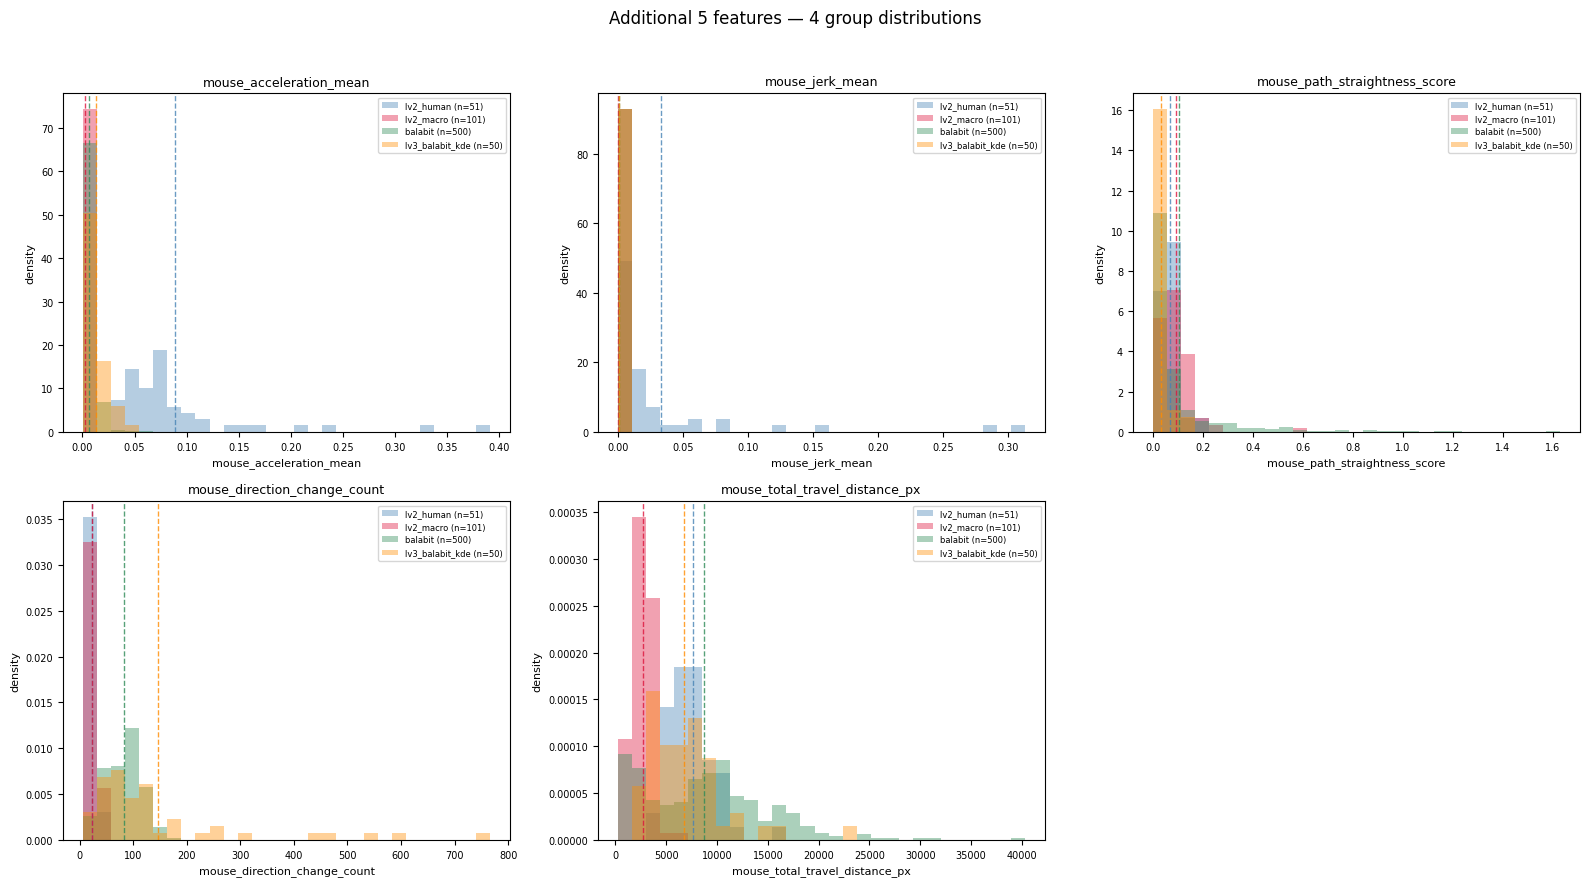

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes_flat = axes.flatten()

for i, feat in enumerate(NEW_FEATURES):
    ax = axes_flat[i]
    values = {g: dfs[g][feat].dropna().values for g in GROUPS}
    combined = np.concatenate(list(values.values()))
    bins = np.linspace(combined.min(), combined.max(), 30)

    for g in GROUPS:
        v = values[g]
        ax.hist(v, bins=bins, alpha=0.4, color=GROUP_COLORS[g],
                label=f"{g} (n={len(v)})", density=True)
        ax.axvline(np.mean(v), color=GROUP_COLORS[g], linestyle="--",
                   linewidth=1.0, alpha=0.8)

    ax.set_title(feat, fontsize=9)
    ax.set_xlabel(feat, fontsize=8)
    ax.set_ylabel("density", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=6)

axes_flat[5].axis("off")
fig.suptitle("Additional 5 features — 4 group distributions", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

## 3. per-group [min, max] + 외부진입율 (두 축) + σ ratio + group min/max 절대값

**축1 (lv2)**: `lv2_macro` [min, max] range → `lv2_human` inside / below / above 비율 (human 다양성 척도)
**축2 (lv3)**: `Balabit_human` [min, max] range → `lv3_balabit_kde` inside / below / above 비율 (lv3 흉내 척도)

비대칭 정당화: 축1 은 macro 좁은 분포가 human 폭을 얼마나 못 잡는지(human 다양성), 축2 는 lv3 매크로가 Balabit_human 폭 안에 얼마나 들어가는지(lv3 흉내). 측정 의도가 다름.

**σ ratio 방향**: `macro_std / human_std` (작을수록 macro 좁음). 핸드오프 baseline 0.136 정합.
- 축1: `lv2_macro_std / lv2_human_std`
- 축2: `lv3_balabit_kde_std / Balabit_human_std`

**Caveat**: `[min, max]` 실측 range 는 outlier 1개로 폭 부풀려질 수 있음. 결과 해석 시 group min/max 절대값 함께 검토 (마지막 표).

In [5]:
def coverage(reference_vals: np.ndarray, target_vals: np.ndarray) -> dict:
    r_min, r_max = float(reference_vals.min()), float(reference_vals.max())
    pct_below  = float((target_vals < r_min).sum()) / len(target_vals) * 100
    pct_above  = float((target_vals > r_max).sum()) / len(target_vals) * 100
    pct_inside = 100 - pct_below - pct_above
    return {
        "ref_min": r_min,
        "ref_max": r_max,
        "pct_below": pct_below,
        "pct_inside": pct_inside,
        "pct_above": pct_above,
    }

def std_ratio_macro_over_human(macro_vals: np.ndarray, human_vals: np.ndarray) -> float:
    h_std = float(np.std(human_vals))
    m_std = float(np.std(macro_vals))
    return (m_std / h_std) if h_std > 0 else float("inf")

def axis1_row(feat: str) -> dict:
    vh = dfs["lv2_human"][feat].dropna().values
    vm = dfs["lv2_macro"][feat].dropna().values
    cov = coverage(vm, vh)
    return {
        "feature": feat,
        "macro_min": cov["ref_min"],
        "macro_max": cov["ref_max"],
        "human_below%": cov["pct_below"],
        "human_inside%": cov["pct_inside"],
        "human_above%": cov["pct_above"],
        "std_ratio_m/h": std_ratio_macro_over_human(vm, vh),
    }

def axis2_row(feat: str) -> dict:
    vbh  = dfs["balabit"][feat].dropna().values
    vlv3 = dfs["lv3_balabit_kde"][feat].dropna().values
    cov = coverage(vbh, vlv3)
    return {
        "feature": feat,
        "balabit_min": cov["ref_min"],
        "balabit_max": cov["ref_max"],
        "lv3_below%": cov["pct_below"],
        "lv3_inside%": cov["pct_inside"],
        "lv3_above%": cov["pct_above"],
        "std_ratio_lv3/balabit": std_ratio_macro_over_human(vlv3, vbh),
    }

def group_minmax_row(feat: str) -> dict:
    row = {"feature": feat}
    for g in GROUPS:
        v = dfs[g][feat].dropna().values
        row[f"{g}_min"] = float(v.min())
        row[f"{g}_max"] = float(v.max())
    return row

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

axis1_df = pd.DataFrame([axis1_row(f) for f in NEW_FEATURES]).set_index("feature")
axis2_df = pd.DataFrame([axis2_row(f) for f in NEW_FEATURES]).set_index("feature")
abs_df   = pd.DataFrame([group_minmax_row(f) for f in NEW_FEATURES]).set_index("feature")

print("=== 축1 (lv2): lv2_macro range -> lv2_human inside/below/above ===")
print(axis1_df.to_string(float_format=lambda x: f"{x:.4g}"))

print()
print("=== 축2 (lv3): Balabit_human range -> lv3_balabit_kde inside/below/above ===")
print(axis2_df.to_string(float_format=lambda x: f"{x:.4g}"))

print()
print("=== group min/max 절대값 (outlier 검토용) ===")
print(abs_df.to_string(float_format=lambda x: f"{x:.4g}"))

=== 축1 (lv2): lv2_macro range -> lv2_human inside/below/above ===
                                macro_min  macro_max  human_below%  human_inside%  human_above%  std_ratio_m/h
feature                                                                                                       
mouse_acceleration_mean          0.001725   0.003087             0              0           100       0.003751
mouse_jerk_mean                   4.4e-05   0.000102             0              0           100      0.0001563
mouse_path_straightness_score    0.005676     0.5953         3.922          96.08             0          1.791
mouse_direction_change_count            7         40             0            100             0           1.28
mouse_total_travel_distance_px      927.1       5828             0          25.49         74.51         0.4188

=== 축2 (lv3): Balabit_human range -> lv3_balabit_kde inside/below/above ===
                                balabit_min  balabit_max  lv3_below%  lv3_inside

## 4. 10 features 단독 분리력 LogReg AUC ranking (두 비교 축)

**축1 (lv2 단독)**: lv2_macro vs lv2_human, 10 features 각각 LogReg(class_weight='balanced', max_iter=1000) 5-fold CV roc_auc.
**축2 (lv3 단독)**: lv3_balabit_kde vs Balabit_human, 동일 시그니처.

**315 시그니처 재현** (`315kde-07-domino` 와 동일):
- `cv=5` 정수 (StratifiedKFold default, shuffle=False)
- `LogisticRegression(class_weight='balanced', max_iter=1000)` (lbfgs default = deterministic)
- `scoring='roc_auc'`
- `random_state` 미명시 (불필요)

**Sanity check**: 5 확정 features × lv3 AUC 가 315 baseline 과 ±0.001 미만 일치 예상. 0.001+ 차이 시 즉시 정지 + trial_loader 데이터 순서 변동 의심.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# 축1: lv2_macro vs lv2_human
sub_lv2 = df_all[df_all["group"].isin(["lv2_human", "lv2_macro"])].dropna(subset=ALL_FEATURES).copy()
y_lv2 = (sub_lv2["group"] == "lv2_macro").astype(int).values

print(f"축1 (lv2): lv2_macro={int(y_lv2.sum())} (pos), lv2_human={int(len(y_lv2)-y_lv2.sum())} (neg), total={len(sub_lv2)}")
print()

axis1_auc_rows = []
for feat in ALL_FEATURES:
    X = sub_lv2[[feat]].values
    aucs = cross_val_score(
        LogisticRegression(class_weight="balanced", max_iter=1000),
        X, y_lv2, cv=5, scoring="roc_auc",
    )
    axis1_auc_rows.append({
        "feature": feat,
        "lv2_auc_mean": float(np.mean(aucs)),
        "lv2_auc_std": float(np.std(aucs)),
    })
axis1_auc_df = pd.DataFrame(axis1_auc_rows).set_index("feature")
print(axis1_auc_df.to_string(float_format=lambda x: f"{x:.4f}"))

축1 (lv2): lv2_macro=101 (pos), lv2_human=51 (neg), total=152



                                lv2_auc_mean  lv2_auc_std
feature                                                  
mouse_acceleration_mean               1.0000       0.0000
mouse_jerk_mean                       1.0000       0.0000
mouse_path_straightness_score         0.6185       0.1140
mouse_direction_change_count          0.4314       0.0582
mouse_total_travel_distance_px        0.9980       0.0024
inter_click_interval_ms               1.0000       0.0000
mouse_speed_change_mean               1.0000       0.0000
mouse_max_speed_px_per_ms             1.0000       0.0000
mouse_path_curvature_mean             0.9735       0.0188
mouse_avg_speed_px_per_ms             0.9847       0.0147


In [7]:
# 축2: lv3_balabit_kde vs Balabit_human
sub_lv3 = df_all[df_all["group"].isin(["lv3_balabit_kde", "balabit"])].dropna(subset=ALL_FEATURES).copy()
y_lv3 = (sub_lv3["group"] == "lv3_balabit_kde").astype(int).values

print(f"축2 (lv3): lv3_balabit_kde={int(y_lv3.sum())} (pos), balabit={int(len(y_lv3)-y_lv3.sum())} (neg), total={len(sub_lv3)}")
print()

axis2_auc_rows = []
for feat in ALL_FEATURES:
    X = sub_lv3[[feat]].values
    aucs = cross_val_score(
        LogisticRegression(class_weight="balanced", max_iter=1000),
        X, y_lv3, cv=5, scoring="roc_auc",
    )
    axis2_auc_rows.append({
        "feature": feat,
        "lv3_auc_mean": float(np.mean(aucs)),
        "lv3_auc_std": float(np.std(aucs)),
    })
axis2_auc_df = pd.DataFrame(axis2_auc_rows).set_index("feature")
print(axis2_auc_df.to_string(float_format=lambda x: f"{x:.4f}"))

# Sanity check: 5 confirmed features lv3 AUC vs 315 baseline
BASELINE_315_LV3_AUC = {
    "inter_click_interval_ms":   0.4349,
    "mouse_speed_change_mean":   0.6331,
    "mouse_max_speed_px_per_ms": 0.7174,
    "mouse_path_curvature_mean": 0.6046,
    "mouse_avg_speed_px_per_ms": 0.6123,
}
SANITY_HARD_THRESHOLD = 0.001

print()
print("=== Sanity check: 5 confirmed features lv3 AUC vs 315 baseline ===")
sanity_rows = []
sanity_failed_features = []
for feat in CONFIRMED_FEATURES:
    cur = float(axis2_auc_df.loc[feat, "lv3_auc_mean"])
    base = BASELINE_315_LV3_AUC[feat]
    delta = cur - base
    sanity_rows.append({
        "feature": feat,
        "320_auc": cur,
        "315_baseline": base,
        "delta": delta,
    })
    if abs(delta) >= SANITY_HARD_THRESHOLD:
        sanity_failed_features.append((feat, delta))

sanity_df = pd.DataFrame(sanity_rows).set_index("feature")
print(sanity_df.to_string(float_format=lambda x: f"{x:.4f}"))

if sanity_failed_features:
    raise RuntimeError(
        f"5 confirmed features lv3 AUC vs 315 baseline delta >= {SANITY_HARD_THRESHOLD}. "
        f"Failed: {sanity_failed_features}. "
        "Stop and report to analysis chat. "
        "Suspect: trial_loader data order variation. Self-correction prohibited."
    )

print()
print(f"[ok] All 5 confirmed features lv3 AUC delta < {SANITY_HARD_THRESHOLD} vs 315 baseline.")

축2 (lv3): lv3_balabit_kde=50 (pos), balabit=488 (neg), total=538



                                lv3_auc_mean  lv3_auc_std
feature                                                  
mouse_acceleration_mean               0.7882       0.1651
mouse_jerk_mean                       0.8108       0.1682
mouse_path_straightness_score         0.6963       0.1277
mouse_direction_change_count          0.5702       0.1773
mouse_total_travel_distance_px        0.6107       0.3006
inter_click_interval_ms               0.4349       0.2700
mouse_speed_change_mean               0.6331       0.1688
mouse_max_speed_px_per_ms             0.7174       0.1436
mouse_path_curvature_mean             0.6046       0.1638
mouse_avg_speed_px_per_ms             0.6123       0.1272

=== Sanity check: 5 confirmed features lv3 AUC vs 315 baseline ===
                           320_auc  315_baseline   delta
feature                                                 
inter_click_interval_ms     0.4349        0.4349  0.0000
mouse_speed_change_mean     0.6331        0.6331 -0.0000
mouse_ma

In [8]:
# 분류 (cutoff 0.65, borderline 0.65~0.72)
CUTOFF_LOWER = 0.65
BORDERLINE_UPPER = 0.72

def classify(lv2: float, lv3: float, lower: float = CUTOFF_LOWER, upper: float = BORDERLINE_UPPER) -> str:
    if lv2 < lower and lv3 < lower:
        return "no_signal"
    if lv2 < lower and lv3 >= lower:
        return "lv3_only"
    # lv2 >= lower
    if lv3 < lower:
        return "domino"
    if lv3 < upper:
        return "borderline"
    return "robust"

rank_rows = []
for feat in ALL_FEATURES:
    lv2 = float(axis1_auc_df.loc[feat, "lv2_auc_mean"])
    lv3 = float(axis2_auc_df.loc[feat, "lv3_auc_mean"])
    rank_rows.append({
        "feature": feat,
        "lv2_auc": lv2,
        "lv3_auc": lv3,
        "category": classify(lv2, lv3),
    })

rank_df = pd.DataFrame(rank_rows).set_index("feature")
rank_df = rank_df.sort_values("lv3_auc", ascending=False)

print(f"=== Combined ranking (cutoff {CUTOFF_LOWER}, borderline {CUTOFF_LOWER}~{BORDERLINE_UPPER}) ===")
print(rank_df.to_string(float_format=lambda x: f"{x:.4f}"))

print()
print("Category counts:")
print(rank_df["category"].value_counts().to_string())

=== Combined ranking (cutoff 0.65, borderline 0.65~0.72) ===
                                lv2_auc  lv3_auc    category
feature                                                     
mouse_jerk_mean                  1.0000   0.8108      robust
mouse_acceleration_mean          1.0000   0.7882      robust
mouse_max_speed_px_per_ms        1.0000   0.7174  borderline
mouse_path_straightness_score    0.6185   0.6963    lv3_only
mouse_speed_change_mean          1.0000   0.6331      domino
mouse_avg_speed_px_per_ms        0.9847   0.6123      domino
mouse_total_travel_distance_px   0.9980   0.6107      domino
mouse_path_curvature_mean        0.9735   0.6046      domino
mouse_direction_change_count     0.4314   0.5702   no_signal
inter_click_interval_ms          1.0000   0.4349      domino

Category counts:
category
domino        5
robust        2
borderline    1
lv3_only      1
no_signal     1


In [9]:
# Cutoff 민감도 (0.65 vs 0.70). lower 만 변경, upper(0.72) 고정.
def count_by_category(lower: float, upper: float = BORDERLINE_UPPER) -> dict:
    cnt = {"robust": 0, "borderline": 0, "domino": 0, "no_signal": 0, "lv3_only": 0}
    for feat in ALL_FEATURES:
        lv2 = float(axis1_auc_df.loc[feat, "lv2_auc_mean"])
        lv3 = float(axis2_auc_df.loc[feat, "lv3_auc_mean"])
        c = classify(lv2, lv3, lower=lower, upper=upper)
        cnt[c] += 1
    return cnt

c065 = count_by_category(0.65)
c070 = count_by_category(0.70)

def fmt(c: dict) -> str:
    return f"robust={c['robust']}, borderline={c['borderline']}, domino={c['domino']}, no_signal={c['no_signal']}, lv3_only={c['lv3_only']}"

print(f"cutoff 0.65 (border 0.65~0.72): {fmt(c065)}")
print(f"cutoff 0.70 (border 0.70~0.72): {fmt(c070)}")

cutoff 0.65 (border 0.65~0.72): robust=2, borderline=1, domino=5, no_signal=1, lv3_only=1
cutoff 0.70 (border 0.70~0.72): robust=2, borderline=1, domino=5, no_signal=2, lv3_only=0


## 5. 10 features pair correlation (320-C)

**목적**: redundant pair 식별 (|r| > 0.8) — 채택/제외 결정 X (320-D scope).

**데이터**: 4 그룹 통합 `df_all` + `dropna(subset=ALL_FEATURES)` (ICI 12 NaN balabit 제거 → ~690 row 예상).

**산출**:
1. 10×10 Pearson `|r|` 매트릭스 + heatmap (signed corr 색상)
2. `|r| > 0.8` redundant pair 명단 (pooled 기준)
3. 채택 후보 4 (`mouse_jerk_mean` / `mouse_acceleration_mean` / `mouse_max_speed_px_per_ms` / `mouse_path_straightness_score`) 상호 |r| (320-D 입력)
4. 그룹별 |r| 보조 산출 — pooled 와 그룹 평균 차이 > 0.2 면 Simpson paradox 경고

**중요**: jerk = acceleration 시간 미분이라 강한 상관 예상.

Total rows after dropna(subset=ALL_FEATURES): 690 (from 702)

=== |r| 매트릭스 (4 group pooled) ===
                                mouse_acceleration_mean  mouse_jerk_mean  mouse_path_straightness_score  mouse_direction_change_count  mouse_total_travel_distance_px  inter_click_interval_ms  mouse_speed_change_mean  mouse_max_speed_px_per_ms  mouse_path_curvature_mean  mouse_avg_speed_px_per_ms
mouse_acceleration_mean                           1.000            0.884                          0.032                         0.188                           0.016                    0.040                    0.643                      0.551                      0.336                      0.527
mouse_jerk_mean                                   0.884            1.000                          0.019                         0.114                           0.003                    0.026                    0.387                      0.338                      0.199                      0.287
mouse_path_st

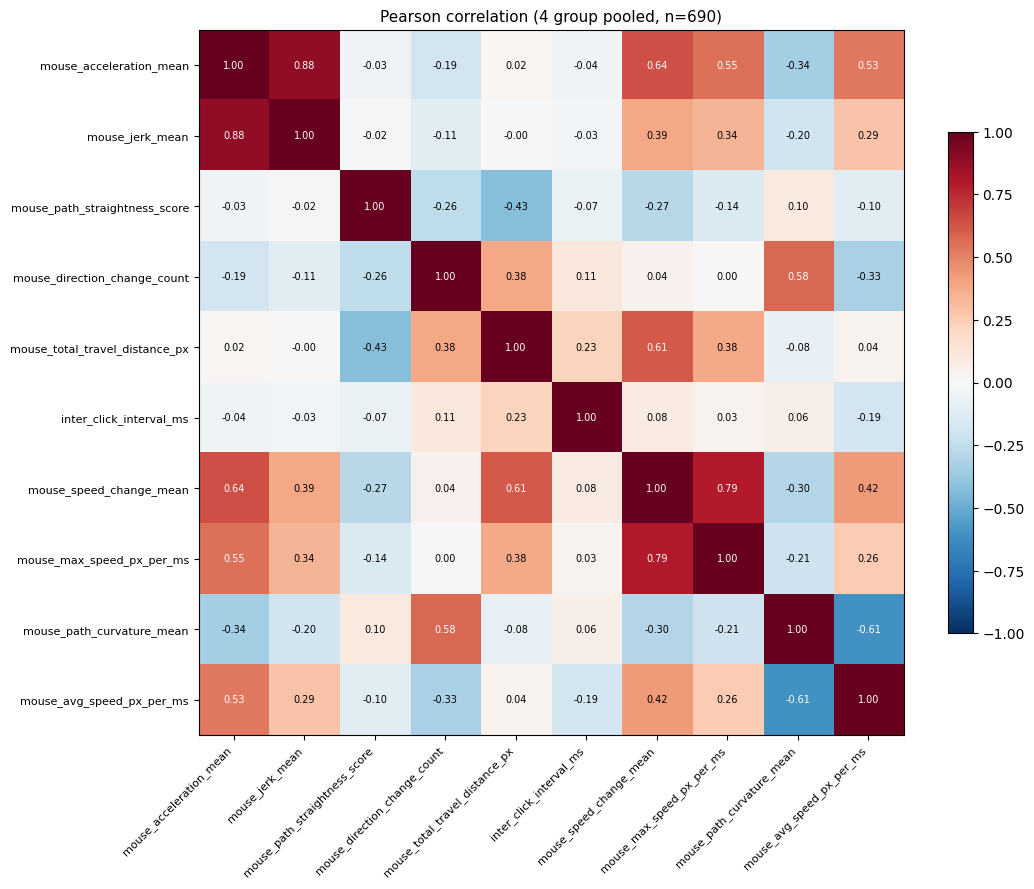

In [10]:
# 4 그룹 통합 + dropna
sub_all = df_all.dropna(subset=ALL_FEATURES).copy()
print(f"Total rows after dropna(subset=ALL_FEATURES): {len(sub_all)} (from {len(df_all)})")
print()

corr_all = sub_all[ALL_FEATURES].corr()
abs_corr = corr_all.abs()

print("=== |r| 매트릭스 (4 group pooled) ===")
print(abs_corr.to_string(float_format=lambda x: f"{x:.3f}"))

# Heatmap (matplotlib imshow + ax.text annot, seaborn 의존성 제거)
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr_all.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="equal")
plt.colorbar(im, ax=ax, shrink=0.7)
ax.set_xticks(range(len(ALL_FEATURES)))
ax.set_yticks(range(len(ALL_FEATURES)))
ax.set_xticklabels(ALL_FEATURES, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(ALL_FEATURES, fontsize=8)
for i in range(len(ALL_FEATURES)):
    for j in range(len(ALL_FEATURES)):
        v = corr_all.values[i, j]
        text_color = "white" if abs(v) > 0.5 else "black"
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", color=text_color, fontsize=7)
ax.set_title(f"Pearson correlation (4 group pooled, n={len(sub_all)})", fontsize=11)
fig.tight_layout()
plt.show()

In [11]:
# Redundant pair (|r| > CORR_CUTOFF) 식별
CORR_CUTOFF = 0.8

# 상삼각 (i < j) pair 추출
pair_rows = []
for i, fi in enumerate(ALL_FEATURES):
    for j, fj in enumerate(ALL_FEATURES):
        if j <= i:
            continue
        r = float(corr_all.loc[fi, fj])
        if abs(r) > CORR_CUTOFF:
            pair_rows.append({
                "feature_1": fi,
                "feature_2": fj,
                "r_pooled": r,
                "abs_r_pooled": abs(r),
            })

if pair_rows:
    pairs_df = pd.DataFrame(pair_rows).sort_values("abs_r_pooled", ascending=False)
else:
    pairs_df = pd.DataFrame(columns=["feature_1", "feature_2", "r_pooled", "abs_r_pooled"])

print(f"=== |r| > {CORR_CUTOFF} redundant pairs (pooled, n={len(sub_all)}): count = {len(pairs_df)} ===")
if len(pairs_df) == 0:
    print("(none)")
else:
    print(pairs_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print()

# 채택 후보 4 상호 |r| (pooled)
ROBUST_CANDIDATES = [
    "mouse_jerk_mean",
    "mouse_acceleration_mean",
    "mouse_max_speed_px_per_ms",
    "mouse_path_straightness_score",
]
print(f"=== 채택 후보 {len(ROBUST_CANDIDATES)} 상호 |r| (pooled) ===")
print(abs_corr.loc[ROBUST_CANDIDATES, ROBUST_CANDIDATES].to_string(float_format=lambda x: f"{x:.3f}"))

print()

# 그룹별 |r| (채택 후보 4 한정)
group_corrs_subset = {}
for g in GROUPS:
    sub_g = dfs[g].dropna(subset=ALL_FEATURES)
    if len(sub_g) >= 5:
        group_corrs_subset[g] = sub_g[ROBUST_CANDIDATES].corr().abs()
    else:
        group_corrs_subset[g] = None

cand_pair_rows = []
for i, fi in enumerate(ROBUST_CANDIDATES):
    for j, fj in enumerate(ROBUST_CANDIDATES):
        if j <= i:
            continue
        row = {
            "pair": f"{fi} / {fj}",
            "r_pooled": float(abs_corr.loc[fi, fj]),
        }
        per_group = []
        for g in GROUPS:
            gc = group_corrs_subset[g]
            if gc is not None:
                rv = float(gc.loc[fi, fj])
                row[f"r_{g}"] = rv
                per_group.append(rv)
            else:
                row[f"r_{g}"] = float("nan")
        if per_group:
            row["r_group_mean"] = float(np.mean(per_group))
            row["delta_pooled_minus_groupmean"] = row["r_pooled"] - row["r_group_mean"]
        cand_pair_rows.append(row)

cand_df = pd.DataFrame(cand_pair_rows)
print("=== 채택 후보 상호 |r| pooled vs 그룹별 (Simpson paradox 검토) ===")
print(cand_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# Simpson paradox 경고
print()
SIMPSON_DELTA_THRESHOLD = 0.2
sim_warn = cand_df[cand_df["delta_pooled_minus_groupmean"].abs() > SIMPSON_DELTA_THRESHOLD]
if len(sim_warn) == 0:
    print(f"[ok] 채택 후보 상호 |r| pooled vs 그룹 평균 차이 모두 ≤ {SIMPSON_DELTA_THRESHOLD} (Simpson paradox 위험 낮음)")
else:
    print(f"[!] 차이 > {SIMPSON_DELTA_THRESHOLD} pair {len(sim_warn)}건. Simpson paradox 영향 320-D 검토 필요.")
    print(sim_warn.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

=== |r| > 0.8 redundant pairs (pooled, n=690): count = 1 ===
              feature_1       feature_2  r_pooled  abs_r_pooled
mouse_acceleration_mean mouse_jerk_mean    0.8835        0.8835

=== 채택 후보 4 상호 |r| (pooled) ===
                               mouse_jerk_mean  mouse_acceleration_mean  mouse_max_speed_px_per_ms  mouse_path_straightness_score
mouse_jerk_mean                          1.000                    0.884                      0.338                          0.019
mouse_acceleration_mean                  0.884                    1.000                      0.551                          0.032
mouse_max_speed_px_per_ms                0.338                    0.551                      1.000                          0.142
mouse_path_straightness_score            0.019                    0.032                      0.142                          1.000

=== 채택 후보 상호 |r| pooled vs 그룹별 (Simpson paradox 검토) ===
                                                     pair  r_pooled  r_

## 6. Final Feature Set (시나리오 A — 보수적 MVP)

**Final pool: 2 features** (10 평가 후 채택)

| # | feature | lv2 AUC | lv3 AUC | category | 채택 사유 |
|---|---|---|---|---|---|
| 1 | `mouse_jerk_mean` | 1.0000 | **0.8108** | robust | lv2/lv3 양 축 강한 분리력. `mouse_acceleration_mean` 과 redundant (\|r\| 0.884, 그룹별 0.81~0.98) 이지만 lv3 AUC 약간 높아 채택. |
| 2 | `mouse_max_speed_px_per_ms` | 1.0000 | **0.7174** | borderline | lv2 단독 1.0000, lv3 cutoff 0.72 미달 0.0026 (0.65/0.70 양 cutoff 모두 borderline). 보수적 MVP 단계라 채택 — 운영 데이터 누적 후 재평가. |

**제외 8 features** (분류별 그루핑)

- **redundant (1)**: `mouse_acceleration_mean` — `mouse_jerk_mean` 와 \|r\| 0.884 강한 상관 (jerk = acceleration 시간 미분), jerk 채택으로 충분.
- **lv3_only (1)**: `mouse_path_straightness_score` — lv2 AUC 0.6185 (cutoff 0.65 미달 0.0315), lv3 AUC 0.6963. cutoff 0.65 lv3_only → 0.70 no_signal (민감). MVP 보수적 제외.
- **no_signal (1)**: `mouse_direction_change_count` — lv2 AUC 0.4314 (0.5 미만, 반전 영역), lv3 AUC 0.5702. 양 축 모두 분리력 약함. lv3 max 766 outlier 의심도 LogReg AUC 영향 약함 확인.
- **domino (5)**: lv2 강력 (≥ 0.97) but lv3 < 0.65
  - `inter_click_interval_ms` (lv2 1.0000 / lv3 0.4349)
  - `mouse_speed_change_mean` (lv2 1.0000 / lv3 0.6331)
  - `mouse_path_curvature_mean` (lv2 0.9735 / lv3 0.6046)
  - `mouse_avg_speed_px_per_ms` (lv2 0.9847 / lv3 0.6123)
  - `mouse_total_travel_distance_px` (lv2 0.9980 / lv3 0.6107)

**시나리오 A 근거**: 보수적 MVP 시작 (final pool 2개) + 운영 데이터로 continuous improvement. lv3-style (KDE 흉내) 매크로 보조 신호 (`path_straightness_score` 등) 는 운영 재평가 시점에 도입 검토.

## 7. Monitoring 후보 + 운영 데이터 정책

**yaml 44 정본 변경 X** — BE/client 수집 계속, 운영 데이터에 보존. ML 학습 input pool 에서만 채택 2 features 사용.

### yaml 44 - 채택 2 = 42 features (운영 모니터링 후보)

채택 외 모든 features 운영 데이터에 수집 + drift 모니터링. 다음 재평가 ticket 입력.

### Balabit 결측 6 features (옵션 B 적용)

ML 학습 input pool 에서만 제외 (lv2_human 1인 vs Balabit derived 개인 편향 위험으로 정량 비교 부적합). yaml / 수집 / 운영 데이터 보존 계속.

- `time_to_first_click_ms`
- `pre_click_mousemove_count`
- `mouse_overshoot_flag`
- `mouse_hover_dwell_time_ms`
- `mouse_stop_segment_count`
- `mousemove_event_rate`

### 보조 신호 후보 (운영 재평가 시점 검토)

- `mouse_path_straightness_score` — lv3-style (KDE 흉내) 매크로 detector 보조 신호 후보. lv3 AUC 0.6963 + path 직선성 indicator. lv2 AUC 0.62 약하나 lv3 영역 분리에 기여 가능. cutoff 민감해 MVP 제외했지만 운영 lv3 매크로 출현 시 도입 검토.
- `mouse_acceleration_mean` — redundant 제외이지만 `mouse_jerk_mean` monitoring 과 cross-check 가능. drift 시 둘 중 한 쪽 이상 신호 발생 시 alert.

## 8. §미해결 (별도 ticket)

| # | 항목 | 분류 | 후속 |
|---|---|---|---|
| 1 | keyboard 10 features BE 명세 정합성 | BE/AI 명세 | 별도 ticket (BE/AI yaml 정합성 검증) |
| 2 | `mouse_max_speed_px_per_ms` lv3 AUC 0.7174 본질 보강 | 매크로 알고리즘 | 별도 매크로 ticket (KDE bandwidth / trace pool 다양성, 핸드오프 §5.2) |
| 3 | `inter_click_interval_ms` σ ratio 0.14 본질 보강 | 매크로 알고리즘 | 별도 ticket (Balabit raw long-tail RDP idle KDE 미반영, 핸드오프 §5.3) |
| 4 | ADR-XXX 좌표계 적합성: client JS metric 정의 일치 검증 | Detector 운영 prereq | 별도 ticket (FE/AI metric 정의 일치) |
| 5 | CLAUDE.md "학습 누적 git 추적" 표현 갱신 | 컨벤션 | 별도 ticket (320 발견 정책 vs 실제 `.gitignore tasks/` 모순) |

## 9. 모델 확정 (320-E)

**채택 알고리즘**: XGBoost (baseline)

**Hyperparameters** (찬혁 베이스라인 계승):
- `n_estimators`: 400
- `max_depth`: 3
- `learning_rate`: 0.03

**입력 features** (320 final pool, 2 개):
- `mouse_jerk_mean` (robust, lv3 AUC 0.8108)
- `mouse_max_speed_px_per_ms` (borderline, lv3 AUC 0.7174)

**결정 근거**:
- production-ready MVP 우선 — 단순 알고리즘 (XGBoost) + 안정적 hyperparam (찬혁 검증 완료) 조합
- 운영 데이터 누적 후 continuous improvement — 다음 ticket 319 영역에서 hyperparam 튜닝 + 데이터 재평가
- 보수적 채택: lv2/lv3 양 축 검증된 2 feature 만 사용 (overfitting 위험 최소화)
- LightGBM / CatBoost 비교는 **운영 후 재평가로 미룸** — 320 scope 내에서 모델 비교 X (운영 데이터 누적되어야 의미 있음)

**다음 작업 (별도 ticket 319)**: 모델 학습 + 검증 cell 작성, hyperparam 튜닝, 운영 metrics 측정.